In [4]:
import trainer2 as trainer

/home/gowrav8849/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import torch
from torch_geometric.datasets import KarateClub
# Load the dataset
dataset = KarateClub()
# Access the graph
data = dataset[0]
print(data)
# Example output: Data(x=[34, 34], edge_index=[2, 78], y=[34])


In [5]:
from torch.utils.data import DataLoader
from train_functions import build_A_batch
import torch.nn.functional as F
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

def load_data(dataset_name, args):
    # Data Loading ----------------------------------
    dataset = trainer.load_nc_dataset(dataset_name, args.sub_dataname)
    data_ = trainer.nc_to_data(dataset, dataset_name, device)
    labels = data_.y
    unique_labels = torch.unique(labels)
    label_map = {old.item(): i for i, old in enumerate(unique_labels)}
    data_.y = torch.tensor([label_map[x.item()] for x in labels], device=labels.device)
    num_classes = int(data_.y.max().item()) + 1

    # Normalize features
    data_.x = data_.x / data_.x.sum(dim=1, keepdim=True).clamp(min=1)
    num_nodes = data_.num_nodes


    return data_

def get_emb(model, data, batching=True, batch_size=1024, return_logits=True):
    model.eval()
    device = data.x.device
    num_nodes = data.num_nodes
    nodes = torch.arange(num_nodes, device=device)

    if not batching:
        with torch.no_grad():
            out = model(data.x, data.edge_index)
        return out
    # ---- batching ----
    loader = DataLoader(nodes, batch_size=batch_size, shuffle=False)
    out_list = []
   
    with torch.no_grad(): 
        for batch_nodes in loader:
            batch_nodes = batch_nodes.to(device)

            A_batch = build_A_batch(
                data.edge_index,
                batch_nodes,
                data.num_nodes,
                device
            )
            out_batch = model(data.x, data.edge_index, A_batch, batch_nodes)

            out_list.append(out_batch)

    # concatenate all batches
    out = torch.cat(out_list, dim=0)

    return out

In [6]:
import argparse
import sys
def get_args():
    parser = argparse.ArgumentParser(description="LINKX Training Config")

    parser.add_argument('--model_name', type=str, default='LINKX')
    parser.add_argument('--save_dir', type=str, default='results')

    parser.add_argument('--epochs', type=int, default=200)
    parser.add_argument('--lr', type=float, default=5e-3)
    parser.add_argument('--weight_decay', type=float, default=5e-3)

    parser.add_argument('--dropout', type=float, default=0.5)
    parser.add_argument('--batch_size', type=int, default=1024)
    parser.add_argument('--hidden_dim', type=int, default= 32)

    parser.add_argument('--patience', type=int, default=50)

    parser.add_argument('--ignoreA', action='store_true')
    parser.add_argument('--ignoreX', action='store_true')
    parser.add_argument('--debug', action='store_true')

    parser.add_argument('--sub_dataname', type=str, default='')

    if 'ipykernel' in sys.modules:
        args, _ = parser.parse_known_args()
    else:
        args = parser.parse_args()

    return args

In [8]:
args = get_args()
acc, models = trainer.run_experiment(args, dataset_name='fb100')

Cuda available: True

===== DATASET: fb100 =====
Invalid sub_dataname, deferring to Penn94 graph
Creating Num of classes
Created Num of classes
Model Name: LINKX
Num classes: 2
lr: 0.005 | weight_decay: 0.005 | dropout: 0.5 | batch_size: 1024 | hidden_dim: 32 | patience: 50 | epochs: 200
Using FIXED splits: 5

--- Run 0 ---
Test Accuracy: 0.7562

--- Run 1 ---
Early stopping at epoch 170
Test Accuracy: 0.7500

--- Run 2 ---
Early stopping at epoch 168
Test Accuracy: 0.7460

--- Run 3 ---
Early stopping at epoch 51
Test Accuracy: 0.5327

--- Run 4 ---
Test Accuracy: 0.7464

FB100 → Avg Accuracy: 0.7063 ± 0.0869


In [ ]:
args = get_args()
# data = load_data('fb100',args)

In [ ]:
for i in range(len(models)):
    torch.save({
        "model_state_dict": models[i].state_dict(),
        "args": vars(args),          # optional but useful
        "num_classes": data.num_classes,
    }, f"linkx_m{i}_fb100.pt")

In [7]:
from models import LINKXC 

args = get_args()
data = load_data('fb100',args)
# embedding = get_emb(models[0], data_)

# loading the m0 model
checkpoint = torch.load("parameters/fb100_penn94/linkx_m0_fb100.pt", map_location=device)
# HeterophilicGNN/LINKX/parameters
model = LINKXC(
    feat_dim=data.num_features,
    hidden_dim=checkpoint["args"]["hidden_dim"],
    num_nodes=data.num_nodes,
    num_classes=data.num_classes,
    ignoreA=checkpoint["args"]["ignoreA"],
    ignoreX=checkpoint["args"]["ignoreX"],
    dropout=checkpoint["args"]["dropout"]
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

Invalid sub_dataname, deferring to Penn94 graph


/media/gowrav8849/01DCBD313BD452D0/V/sem_6_notes/mini_project/HeterophilicGNN/LINKX/dataset.py:140: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  edge_index = torch.tensor(A.nonzero(), dtype=torch.long)


Creating Num of classes
Created Num of classes


/tmp/ipykernel_8087/883038425.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("parameters/fb100_penn94/linkx_m0_fb100.pt", map_location=device)


LINKXC(
  (MLPX): Linear(in_features=4814, out_features=32, bias=True)
  (W): Linear(in_features=64, out_features=32, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (out): Linear(in_features=32, out_features=2, bias=True)
)

In [8]:
embedding = get_emb(model,data) # forward Pass to get Embeddings i.e X -> X'

In [57]:
import torch

def compute_pairwise_distances(emb):
    # emb: [N, D]
    # returns [N, N]
    dist = torch.cdist(emb, emb, p=2)  # Euclidean
    return dist

def build_adj_list(edge_index, num_nodes):
    adj = [set() for _ in range(num_nodes)]
    row, col = edge_index

    for r, c in zip(row.tolist(), col.tolist()):
        adj[r].add(c)
        adj[c].add(r)  # assuming undirected

    return adj

def compute_recall(knn_indices, adj_list):
    recalls = []

    for i in range(len(knn_indices)):
        pred = set(knn_indices[i].tolist())
        true = adj_list[i]

        if len(true) == 0:
            continue

        hit = len(pred & true)
        recall = hit / len(true)

        recalls.append(recall)

    return sum(recalls) / len(recalls)

import torch.nn.functional as F

def compute_distance(x, chunk, metric="euclidean"):
    """
    x: [1, D]
    chunk: [C, D]
    returns: [1, C]
    """

    if metric == "euclidean":
        return torch.cdist(x, chunk)

    elif metric == "cosine":
        # normalize
        x_norm = F.normalize(x, dim=1)
        chunk_norm = F.normalize(chunk, dim=1)

        sim = torch.matmul(x_norm, chunk_norm.T)  # [1, C]
        return 1 - sim  # convert similarity → distance

    elif metric == "dot":
        sim = torch.matmul(x, chunk.T)  # [1, C]
        return -sim  # higher sim → smaller distance

    elif metric == "l1":
        return torch.cdist(x, chunk, p=1)

    else:
        raise ValueError(f"Unknown metric: {metric}")

In [58]:
def knn_streaming(emb, k=10, chunk_size=4096, metric = 'euclidean'):
    device = emb.device
    N, D = emb.shape

    knn_indices = []

    for i in range(N):
        x = emb[i:i+1]  # [1, D]

        best_dist = None
        best_idx = None

        for start in range(0, N, chunk_size):
            end = min(start + chunk_size, N)

            chunk = emb[start:end]  # [C, D]

            dist = compute_distance(x, chunk, metric= metric)  # [1, C] # =========================================== can use different distnace or similarity metric

            if start <= i < end:
                dist[0, i - start] = float('inf')

            if best_dist is None:
                best_dist = dist
                best_idx = torch.arange(start, end, device=device)
            else:
                best_dist = torch.cat([best_dist, dist], dim=1)
                best_idx = torch.cat([best_idx, torch.arange(start, end, device=device)])

            # keep only top-k so memory never grows
            topk = torch.topk(best_dist, k, largest=False)
            best_dist = topk.values
            best_idx = best_idx[topk.indices[0]]

        knn_indices.append(best_idx.cpu())

    return knn_indices

def knn_streaming_per_idx(emb,i,  k=10, chunk_size=4096, metric = "euclidean"):
    device = emb.device
    N, D = emb.shape

    knn_indices = []

    x = emb[i:i+1]  # [1, D]

    best_dist = None
    best_idx = None

    for start in range(0, N, chunk_size):
        end = min(start + chunk_size, N)

        chunk = emb[start:end]  # [C, D]

        dist = compute_distance(x, chunk, metric= metric)  # [1, C]

        if start <= i < end:
            dist[0, i - start] = float('inf')

        if best_dist is None:
            best_dist = dist
            best_idx = torch.arange(start, end, device=device)
        else:
            best_dist = torch.cat([best_dist, dist], dim=1)
            best_idx = torch.cat([best_idx, torch.arange(start, end, device=device)])

        # keep only top-k so memory never grows
        k_eff = min(k, best_dist.shape[1])
        topk = torch.topk(best_dist, k_eff, largest=False)
        best_dist = topk.values
        best_idx = best_idx[topk.indices[0]]


    return best_idx.cpu()

def common_counts(embedding, adj_list, chunk_size = 4096, metric = 'euclidean'):
    N,D = embedding.shape
    common_lst_counts = []
    for j in range(N):
        knn_indices_idx = knn_streaming_per_idx(embedding, j, k = len(adj_list[j]), chunk_size = chunk_size, metric = metric)
        knn_j = knn_indices_idx.tolist()
        adj_j = adj_list[j]
        common_set = set(knn_j) & set(adj_j)
        common_elements = list(common_set)

        common_lst_counts.append(len(common_set))
    return common_lst_counts

#### Analysing whether neighbours are preserved in final embeddings or not in LINKX

In [61]:
adj_list = build_adj_list(data.edge_index, data.num_nodes)
common_cnt_lst = common_counts(embedding, adj_list, metric = 'dot')

**Used dot product as similarity measure**

In [62]:
top_k = 10

# (node_idx, count)
sorted_nodes = sorted(
    list(enumerate(common_cnt_lst)),
    key=lambda x: x[1],
    reverse=True
)

for i in range(top_k):
    node, cnt = sorted_nodes[i]
    deg = len(adj_list[node])
    print(f"Node {node}: overlap={cnt}, degree={deg}, ratio: {cnt/deg : .3f}",)

Node 38657: overlap=364, degree=3777, ratio:  0.096
Node 10567: overlap=334, degree=4410, ratio:  0.076
Node 7735: overlap=257, degree=2582, ratio:  0.100
Node 22563: overlap=247, degree=2613, ratio:  0.095
Node 7112: overlap=199, degree=3240, ratio:  0.061
Node 25816: overlap=182, degree=2298, ratio:  0.079
Node 852: overlap=141, degree=2543, ratio:  0.055
Node 10796: overlap=121, degree=2249, ratio:  0.054
Node 25947: overlap=94, degree=1946, ratio:  0.048
Node 41462: overlap=65, degree=1563, ratio:  0.042


**Used Cosine Similarity**

In [60]:
top_k = 10

# (node_idx, count)
sorted_nodes = sorted(
    list(enumerate(common_cnt_lst)),
    key=lambda x: x[1],
    reverse=True
)

for i in range(top_k):
    node, cnt = sorted_nodes[i]
    deg = len(adj_list[node])
    print(f"Node {node}: overlap={cnt}, degree={deg}, ratio: {cnt/deg : .3f}",)

Node 10567: overlap=466, degree=4410, ratio:  0.106
Node 38657: overlap=361, degree=3777, ratio:  0.096
Node 7112: overlap=263, degree=3240, ratio:  0.081
Node 22563: overlap=179, degree=2613, ratio:  0.069
Node 7735: overlap=151, degree=2582, ratio:  0.058
Node 25816: overlap=142, degree=2298, ratio:  0.062
Node 10796: overlap=128, degree=2249, ratio:  0.057
Node 852: overlap=123, degree=2543, ratio:  0.048
Node 41462: overlap=83, degree=1563, ratio:  0.053
Node 25947: overlap=81, degree=1946, ratio:  0.042


**Used Euclidian Distance**

In [37]:
top_k = 10

# (node_idx, count)
sorted_nodes = sorted(
    list(enumerate(common_cnt_lst)),
    key=lambda x: x[1],
    reverse=True
)

for i in range(top_k):
    node, cnt = sorted_nodes[i]
    deg = len(adj_list[node])
    print(f"Node {node}: overlap={cnt}, degree={deg}, ratio: {cnt/deg : .3f}",)

Node 10567: overlap=448, degree=4410, ratio:  0.102
Node 38657: overlap=358, degree=3777, ratio:  0.095
Node 7112: overlap=255, degree=3240, ratio:  0.079
Node 22563: overlap=182, degree=2613, ratio:  0.070
Node 7735: overlap=163, degree=2582, ratio:  0.063
Node 25816: overlap=146, degree=2298, ratio:  0.064
Node 10796: overlap=119, degree=2249, ratio:  0.053
Node 852: overlap=99, degree=2543, ratio:  0.039
Node 25947: overlap=85, degree=1946, ratio:  0.044
Node 41462: overlap=81, degree=1563, ratio:  0.052


In [30]:
j = 10567
knn_indices_idx = knn_streaming_per_idx(embedding, j, k = len(adj_list[j]), chunk_size = 4096)
knn_j = knn_indices_idx.tolist()
adj_j = adj_list[j]
common_set = set(knn_j) & set(adj_j)

print("KNN:", knn_j)
print("Adj:", adj_j)
print("Intersection", common_set)

common_elements = list(common_set)
len(common_elements)

KNN: [2919, 3569, 11682, 31170, 36820, 5310, 19530, 4010, 6994, 18448, 35423, 24499, 19523, 34050, 16245, 1511, 4722, 5668, 21031, 7731, 26718, 35976, 14488, 25542, 26890, 17257, 3986, 4521, 26269, 18940, 26818, 9281, 18141, 35477, 535, 27676, 36189, 196, 31019, 24922, 267, 612, 26870, 19369, 10836, 33889, 19157, 9107, 6302, 28379, 28010, 24612, 6217, 19195, 38157, 11806, 36735, 39066, 7824, 35346, 30030, 1072, 23065, 39194, 36908, 40811, 4426, 31069, 6781, 17367, 40262, 4520, 32149, 20488, 5769, 32009, 37591, 8782, 11055, 37730, 2153, 3390, 2322, 17151, 6204, 8647, 17996, 717, 5723, 37026, 40077, 13742, 14055, 18073, 12014, 38429, 14997, 14417, 6920, 40061, 5154, 7048, 21542, 11359, 3873, 14018, 28690, 31732, 11421, 39484, 28312, 10668, 18881, 32142, 6798, 7383, 1608, 7067, 15014, 9888, 30400, 6447, 29902, 12430, 6792, 36843, 38296, 7440, 38766, 40434, 14400, 10275, 27626, 10459, 11360, 27774, 23712, 1980, 9766, 9946, 37504, 594, 36924, 37351, 39536, 24204, 22107, 3297, 940, 15843, 38

448

In [39]:
import torch

node = 10567
top_nearest = 30
emb_i = embedding[node]

dists = torch.norm(embedding - emb_i, dim=1)

# sort
sorted_idx = torch.argsort(dists)

print("Top 10 nearest:", sorted_idx[1:top_nearest])
print("Their distances:", dists[sorted_idx[1:top_nearest]])

Top 10 nearest: tensor([ 3569, 31170,  2919, 36820, 11682,  5310, 19530,  6994,  4010, 35423,
        18448, 24499, 19523, 34050, 16245, 21031,  1511, 26718,  4722,  5668,
        35976,  7731, 14488, 26890, 25542, 17257,  3986,  4521, 26269],
       device='cuda:0')
Their distances: tensor([2.2170e-05, 4.7816e-05, 1.0029e-04, 1.8159e-04, 2.0062e-04, 2.4896e-04,
        3.2712e-04, 3.7890e-04, 4.1772e-04, 5.3535e-04, 5.8388e-04, 6.1880e-04,
        7.0623e-04, 7.2027e-04, 7.9666e-04, 8.1634e-04, 8.4974e-04, 8.5191e-04,
        8.5767e-04, 8.7012e-04, 8.8348e-04, 9.0192e-04, 9.5686e-04, 9.8000e-04,
        9.8171e-04, 1.0369e-03, 1.0832e-03, 1.0958e-03, 1.1117e-03],
       device='cuda:0')


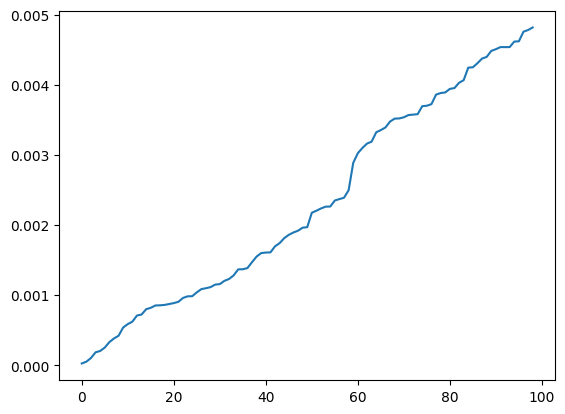

In [43]:
import matplotlib.pyplot as plt 


dist = dists[sorted_idx[1:100]].tolist()
plt.plot(dist)

In [44]:
import random

def random_overlap(node):
    deg = len(adj_list[node])
    rand_nodes = random.sample(range(len(adj_list)), deg)
    return len(set(rand_nodes) & adj_list[node])

node = 10567
print("Random overlap:", random_overlap(node))

Random overlap: 500


In [56]:

N,D = embedding.shape
neighbors = list(adj_list[i])
non_neighbors = list(set(range(N)) - set(neighbors) - {i})

dist_neighbors = dists[neighbors]
dist_non_neighbors = dists[non_neighbors]

print(f"Avg distance neighbours: {dist_neighbors.mean()} , Avg Distance non neighbours{dist_non_neighbors.mean()}")

Avg distance neighbours: 0.9096753001213074 , Avg Distance non neighbours0.9579070210456848


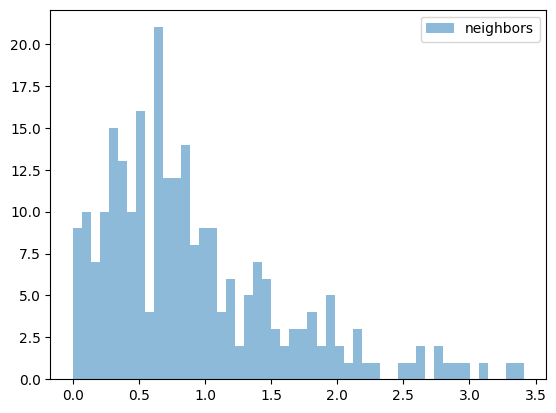

In [55]:
import matplotlib.pyplot as plt

plt.hist(dist_neighbors.cpu(), bins=50, alpha=0.5, label="neighbors")
# plt.hist(dist_non_neighbors.cpu(), bins=50, alpha=0.5, label="non-neighbors")
plt.legend()
plt.show()

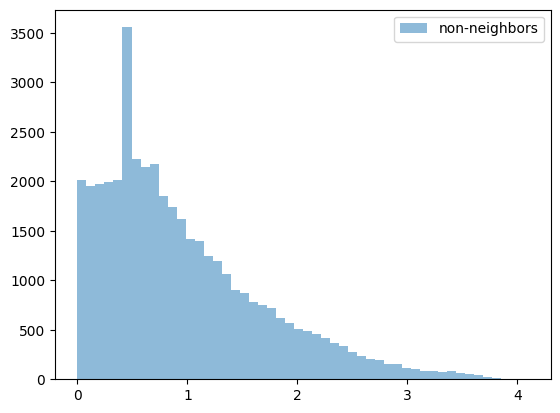

In [54]:
plt.hist(dist_non_neighbors.cpu(), bins=50, alpha=0.5, label="non-neighbors")
plt.legend()
plt.show()
